# Setup

In [71]:
from manim import *
import numpy as np
config.media_width = "75%"
config.verbosity = "WARNING"

# colors

gradient_colors = ["#11998E", "#38EF7D"]

Manim Community v0.18.1

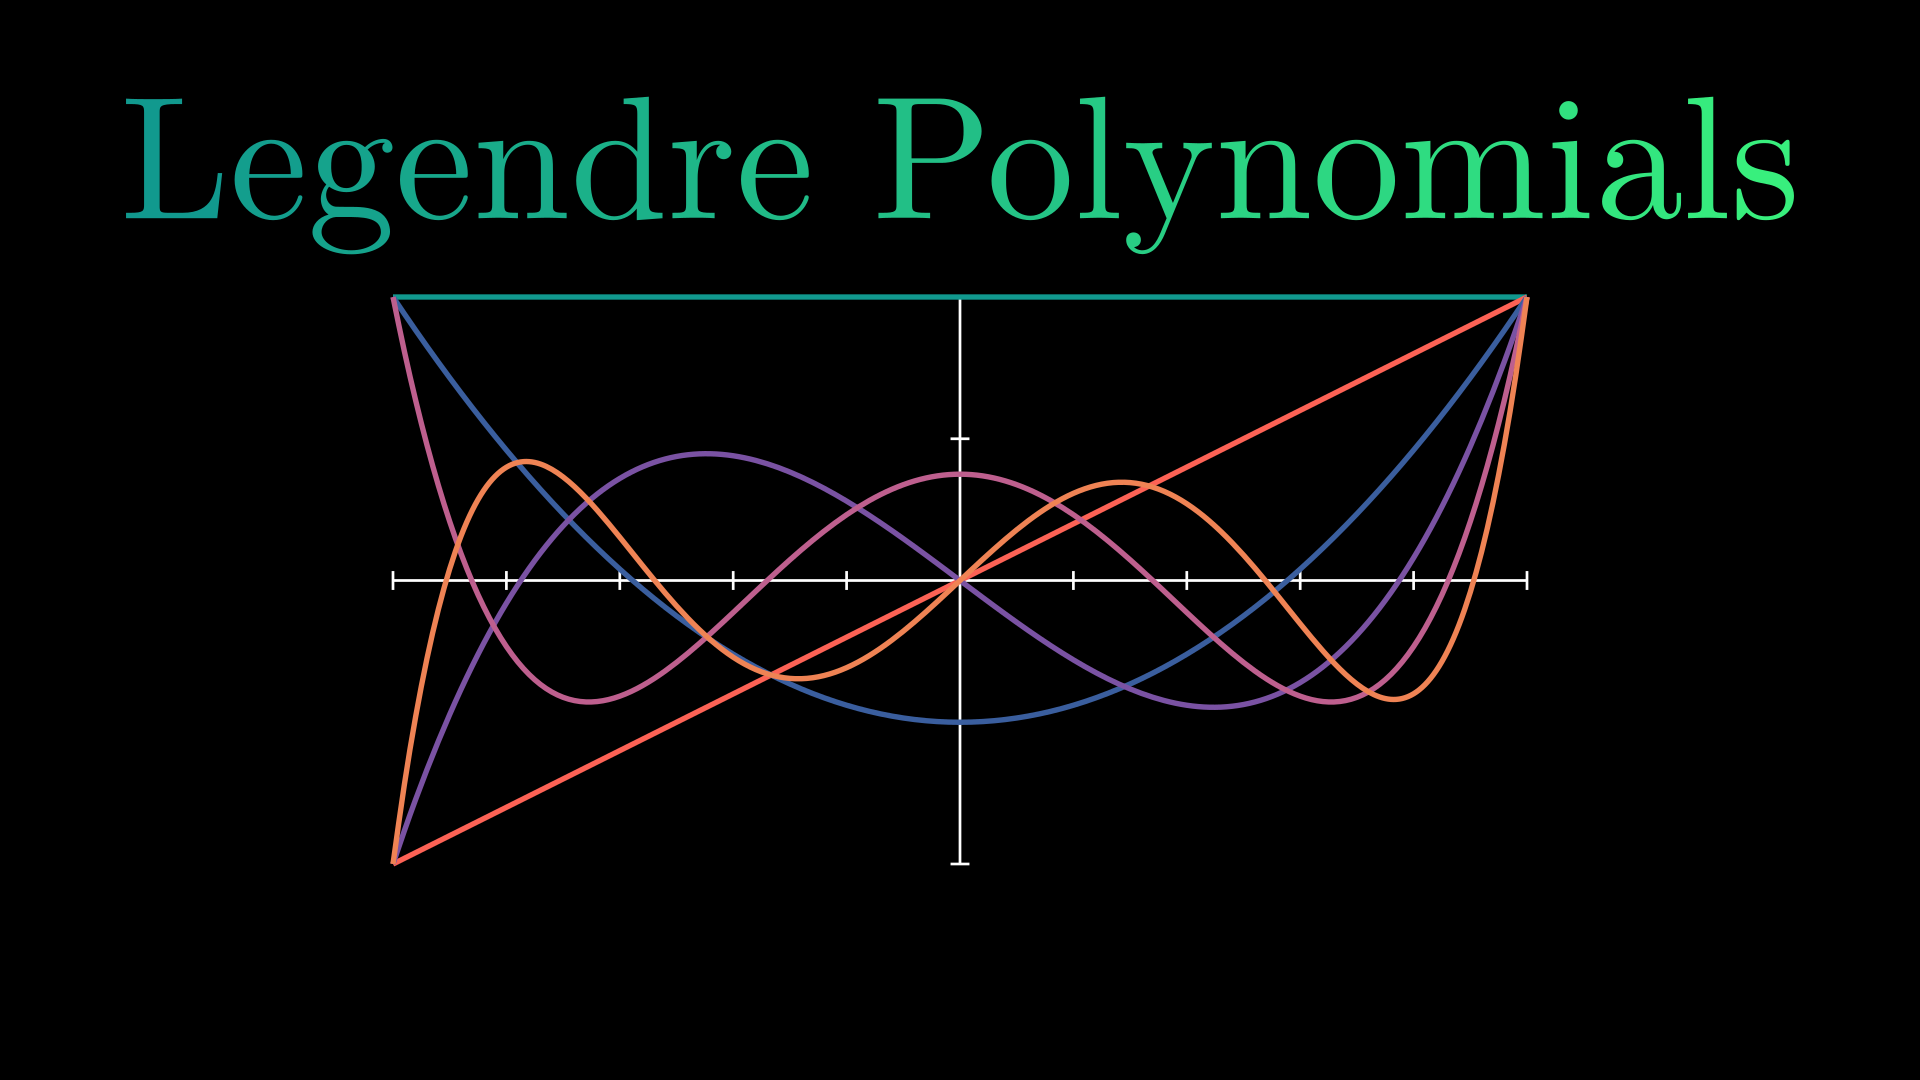

In [90]:
%%manim -qh Thumbnail

class Thumbnail(Scene):
    def legendre_polynomials(self, x, n):
        if n == 0:
            return np.ones_like(x)
        elif n == 1:
            return x
        else:
            Pn_1 = x  # P1(x)
            Pn_2 = np.ones_like(x)  # P0(x)
            for k in range(2, n + 1):
                Pn = ((2 * k - 1) * x * Pn_1 - (k - 1) * Pn_2) / k
                Pn_2, Pn_1 = Pn_1, Pn
            return Pn
    def construct(self):
        title = Tex("Legendre Polynomials", font_size=125)
        title.set_color_by_gradient(*gradient_colors)
        title.move_to(UP*2.7)

        axes = Axes(
            x_range=[-1.0, 1.0, 0.2],
            y_range=[-1.0, 1.0, 0.5],
            tips=False,
            axis_config={"include_numbers": False},
        )

        axes.scale(0.7)
        axes.move_to(DOWN*0.3)
        # Add axes to the scene
        self.add(axes)

        rod = MathTex(r"P_n(x) = \frac{1}{2^nn!} \frac{d^n}{dx^n} [(x^2-1)^n]")
        rod.move_to(DOWN*3)
        bonnet = MathTex(r"(n+1)P_{n+1}(x) = (2n+1)xP_n(x) - nP_{n-1}(x)")
        #bonnet.move_to()
        gen = MathTex(r"g(x,t) = \frac{1}{\sqrt{1-2xt+t^2}}")
        
        # Define colors for the polynomials
        colors = ["#11998E", RED, "#3A5E9E", "#7A52A3", "#BE5F8E", "#EF8354"]
        #colors = [RED, GREEN, BLUE, ORANGE, PURPLE, PINK]

        for n, color in enumerate(colors):
            graph = axes.plot(
                lambda x: self.legendre_polynomials(x,n), 
                x_range = [-1,1],
                color=color
            )

            self.add(graph)

        self.add(title)

# Title

In [32]:
%%manim -qm S1A

class S1A(Scene):
    def construct(self):
        lengdiff = MathTex(r"(1-x^2)y'' - 2xy' + l(l+1)y = 0")

        schr = Tex(r"Schrödinger equation:", r"$$\left(-{\frac {\hbar ^{2}}{2\mu }}\nabla ^{2}-{\frac {e^{2}}{4\pi \varepsilon _{0}r}}\right)\psi (r,\theta ,\varphi )=E\psi (r,\theta ,\varphi )$$")
        schr[0].set_color(TEAL)

        proton = LabeledDot(Tex(r"+", color=BLACK), color=RED)
        electron = LabeledDot(Tex(r"-", color=BLACK), color=BLUE)
        circle = Circle(radius=1.7, color=WHITE)
        circle.set_z_index(-1)
        
        schr.move_to(UP*2.5)
        proton.move_to(DOWN)
        electron.move_to(DOWN + 1.7*RIGHT)
        circle.move_to(proton)
        lengdiff.move_to(DOWN*3.4)
        
        
        self.play(Write(schr))
        self.play(FadeIn(proton, circle, electron))
        self.play(MoveAlongPath(electron, circle), rate_func=linear, run_time=5)
        self.play(MoveAlongPath(electron, circle), rate_func=linear, run_time=5)

Manim Community v0.18.1

In [56]:
%%manim -qm S1B

class S1B(Scene):
    def construct(self):
        title = Tex(r"Gauss-Legendre quadrature", r"$$\int_{-1}^1 f(x)\,dx \approx \sum_{i=1}^n w_if(x_i)$$")
        title[0].set_color(TEAL)
        title.move_to(UP*2.5)

        axes = Axes(
            x_range = [-1.01,1.01,0.5],
            x_length = 4,
            y_range = [-1.01,1.01,0.5],
            y_length = 4,
            tips=False,
            axis_config={"include_numbers": True},
            
        )
        axes.move_to(DOWN*1.5)
        graph = axes.plot(lambda x: -0.5*x**2 + 0.7 -x**4)
        area = axes.get_area(graph, x_range=[-1,1])

        self.play(Write(title))
        self.play(FadeIn(axes, graph, area))
        self.wait()


Manim Community v0.18.1

In [57]:
%%manim -qm S1C

class S1C(Scene):
    def construct(self):
        bonnet = MathTex(r"(n+1)P_{n+1}(x) = (2n+1)xP_n(x) - nP_{n-1}(x)")
        rodrigues = MathTex(r"P_n(x) = \frac{1}{2^nn!} \frac{d^n}{dx^n}[(x^2-1)^n]")
        generating = MathTex(r"g(x,t) = \frac{1}{\sqrt{1-2tx+t^2}}")

        rodrigues.move_to(UP*2)
        generating.move_to(DOWN*2)

        self.play(Write(bonnet))
        self.play(Write(rodrigues))
        self.play(Write(generating))
        self.wait()

Manim Community v0.18.1

In [81]:
%%manim -qm S2

class S2(Scene):
    def construct(self):
        mono = MathTex(r"1, x, x^2, x^3, x^4, x^5, x^6, x^7, x^8, x^9, \dots")
        mono.move_to(UP*2.5)
        arr = Arrow(start = 2*UP + LEFT*2, end = 0*DOWN + LEFT*2)
        label = Tex(r"Orthogonalization")
        label.set_color(TEAL)
        label.next_to(arr, RIGHT)
        poly = MathTex(r"P_0, P_1, P_2, P_3, P_3, P_4, P_5, P_6, P_7, P_8, P_9, \dots")
        poly.set_color_by_gradient(*gradient_colors)
        poly.move_to(DOWN*0.5)

        ortho = MathTex(r"P \perp Q \Leftrightarrow \langle P,Q \rangle = \int_{-1}^1 P(x)Q(x)\,dx = 0")
        ortho.move_to(DOWN*2)

        self.play(Write(mono))
        self.wait()
        self.play(Create(arr), Write(label))
        self.play(Write(poly))
        self.wait()
        self.play(Write(ortho))
        self.wait()

        fig1 = VGroup(mono, arr, label, poly)

        gram = Tex(r"Gram-Schmidt process")
        gram.set_color(TEAL)
        gram.move_to(UP*3)

        self.play(FadeOut(ortho), fig1.animate.shift(DOWN))
        self.play(Write(gram))
        self.wait()
        self.play(FadeOut(fig1))
        self.wait()

        bef = MathTex(r"v_1", r", ", r"v_2")
        bef[0].set_color(RED)
        bef[2].set_color(GREEN)
        pro = MathTex(r"\xrightarrow{}")
        aft = MathTex(r"u_1, u_2")
        bef.move_to(UP*2 + LEFT*1.5)
        pro.move_to(UP*2)
        aft.move_to(UP*2 + RIGHT*1.5)

        self.play(FadeIn(bef, pro, aft))
        self.wait()
        

        utov1 = MathTex(r"u_2 = v_2 - \frac{\langle v_2, u_1 \rangle}{\langle u_1, u_1 \rangle} u_1")
        utov1.move_to(DOWN*2)

        vec1 = Vector([1,2])
        vec1.set_color(RED)
        
        vec2 = Vector([-3, 1])
        vec2.set_color(GREEN)
        proj = Vector([-1/np.sqrt(5), -2/np.sqrt(5)])
        proj.set_color(YELLOW)
        line = Line(start=[-1/np.sqrt(5), -2/np.sqrt(5),0], end=[-3, 1,0])
        line.set_z_index(-1)
        right1 = Angle(Line(start=[-1/np.sqrt(5), -2/np.sqrt(5),0], end=[0, 0,0]), line, dot=True)
        vec2n = Vector([-3 + 1/np.sqrt(5),1 + 2/np.sqrt(5)])
        right2 = Angle(Line(start=[0,0,0], end=[1,2,0]), Line(start=[0,0,0], end=[-3 + 1/np.sqrt(5),1 + 2/np.sqrt(5),0]), dot=True)

        vecstuff = VGroup(vec1, vec2, proj, vec2n, right2)
        right1.shift(DOWN)
        line.shift(DOWN)
        vecstuff.shift(DOWN)

        self.play(Create(vec1), Create(vec2))
        self.wait()
        self.play(Create(line))
        self.play(Create(proj))
        self.play(Create(right1))
        self.wait()
        
        self.wait()
        self.play(proj.animate.shift((-3 + 1/np.sqrt(5))*RIGHT + (1 + 2/np.sqrt(5))*UP), FadeOut(line,right1))
        self.wait()
        self.play(Create(vec2n))
        self.wait()
        self.play(Create(right2))
        self.wait()        
        self.play(Write(utov1))
        self.wait()

        self.play(FadeOut(bef, aft, vecstuff, utov1))

        mbef = MathTex(r"v_1,v_2,\dots,v_n")
        maft = MathTex(r"u_1,u_2,\dots,u_n")
        mbef.move_to(UP*2 + LEFT*2.5)
        maft.move_to(UP*2 + RIGHT*2.5)

        self.play(FadeIn(mbef,maft))
        self.wait()

        proctex1 = VGroup(
            MathTex(r"u_1 = v_1"),
             MathTex(r"\vdots"),
            MathTex(r"u_k = v_k - \sum_{i=1}^k\frac{\langle v_k, u_i \rangle}{\langle u_i, u_i \rangle} u_i")
        )
        proctex1[0].move_to(UP*0.5)
        proctex1[1].move_to(DOWN*0.7)
        proctex1[2].move_to(DOWN*2.5)
        self.play(FadeIn(proctex1))
        self.wait()
        self.play(FadeOut(proctex1, mbef, maft, gram, pro))
        fig1.shift(UP*1.5)
        self.play(FadeIn(fig1))
        fina1 = Tex(r"$\leadsto$ able to calculate $P_n$")
        fina1.move_to(DOWN*1)
        fina2 = Tex(r"$P_n$ unique up to multiple")
        fina2.move_to(DOWN*2)
        fina3 = Tex(r"Normalization condition: $P_n(1) = 1$")
        fina3.move_to(DOWN*2)
        self.wait()
        self.play(Write(fina1))
        self.wait()
        self.play(FadeIn(fina2))
        self.wait()
        self.play(Transform(fina2, fina3))
        self.wait()
        self.play(FadeOut(mono, arr, label, fina1, fina2, fina3), poly.animate.shift(UP*2.5))

        otex2 = MathTex(r"\deg(P_n) = n")
        otex3 = Tex(r"$\langle P_n, x^m \rangle = 0$ for $m < n$")
        otex3n = Tex(r"$\langle P_n, Q \rangle = 0$ if $\deg(Q) < n$")
        otex4 = MathTex(r"P_n(1) = 1")
        otex2.move_to(UP*1.3)
        otex4.move_to(DOWN*1.3)

        self.play(Write(otex2))
        self.play(Write(otex3))
        self.play(Write(otex4))
        self.wait()
        self.play(Transform(otex3, otex3n))
        self.wait()

        legtex = Tex(r"Legendre polynomials")
        legtex.set_color_by_gradient(*gradient_colors)
        legtex.move_to(DOWN*2.5)

        self.play(Write(legtex))
        self.wait()
        self.play(FadeOut(poly, otex2, otex3, otex4, legtex))

Manim Community v0.18.1

In [15]:
%%manim -qm S3

class S3(Scene):
    def legendre_polynomials(self, x, n):
        if n == 0:
            return np.ones_like(x)
        elif n == 1:
            return x
        else:
            Pn_1 = x  # P1(x)
            Pn_2 = np.ones_like(x)  # P0(x)
            for k in range(2, n + 1):
                Pn = ((2 * k - 1) * x * Pn_1 - (k - 1) * Pn_2) / k
                Pn_2, Pn_1 = Pn_1, Pn
            return Pn
            
    def construct(self):
        con1 = Tex(r"Legendre polynomials")
        con1[0].set_color_by_gradient(*gradient_colors)
        con1.move_to(UP*3.5)
        self.play(Write(con1))
        
        axes = Axes(
            x_range=[-1.2, 1.2, 0.2],
            y_range=[-1.5, 1.5, 0.5],
            tips=False,
            axis_config={"include_numbers": True},
        ).add_coordinates()
        axes2 = axes.copy()

        
        # Add axes to the scene
        self.play(Create(axes))

        # Define colors for the polynomials
        colors = [RED, GREEN, BLUE, ORANGE, PURPLE, PINK]

        odds = VGroup(axes)
        evens = VGroup(axes2)

        # Plot and animate the first few Legendre polynomials
        for n, color in enumerate(colors):
            graph = axes.plot(
                lambda x: self.legendre_polynomials(x,n), 
                x_range = [-1,1],
                color=color
            )

            if n % 2 == 0:
                evens.add(graph)
            else:
                odds.add(graph)
            self.play(Create(graph))
            #self.add(graph)
            
        self.wait()

        self.play(evens.animate.scale(0.4), odds.animate.scale(0.4))
        self.play(evens.animate.shift(LEFT*3 + UP*2), odds.animate.shift(RIGHT*3 + UP*2))
        self.wait()
        labax1 = Tex(r"$P_0$, $P_2$, $P_4$")
        labax1.next_to(axes2, DOWN)
        labax2 = Tex(r"$P_1$, $P_3$, $P_5$")
        labax2.next_to(axes, DOWN)
        self.play(FadeIn(labax1, labax2))
        self.wait()

        pro1 = MathTex(r"\deg(P_n(-x)) = n")
        pro2 = MathTex(r"\text{If } \deg(Q) < n \text{, then }")
        pro3 = MathTex(r"\langle P_n(-x), Q(x) \rangle = \langle P_n(-x),Q(-(-x)) \rangle", r"= \langle P_n(x),Q(-x) \rangle = 0")
        pro4 = MathTex(r"\Rightarrow P_n(-x) = \lambda P_n(x)")
        pro1.move_to(DOWN*0.5)
        pro2.move_to(DOWN*1.5)
        pro3.move_to(DOWN*2.5)
        pro4.move_to(DOWN*3.5)

        self.play(Write(pro1))
        self.wait()
        self.play(Write(pro2))
        self.play(Write(pro3[0]))
        self.wait()
        self.play(Write(pro3[1]))
        self.wait()
        self.play(Write(pro4))
        self.wait()
        self.play(FadeOut(pro1,pro2,pro3), pro4.animate.shift(UP*3))
        self.wait()

        pro5 = MathTex(r"\lambda \langle P_n(x),x^n \rangle = \langle P_n(-x), x^n \rangle = ", r"(-1)^n\langle P_n(-x), (-x)^n \rangle")
        pro52 = MathTex(r"(-1)^n\langle P_n(x),x^n \rangle")
        pro5.move_to(DOWN*1.5)
        pro52.next_to(pro5[0], RIGHT)
        pro6 = MathTex(r"P_n(-x) = (-1)^nP(x)")
        pro6.move_to(DOWN*2.5)

        self.play(Write(pro5))
        self.wait()
        self.play(Transform(pro5[1], pro52))
        self.wait()
        self.play(Write(pro6))
        self.wait()
        self.play(FadeOut(pro4, pro5))
        self.play(pro6.animate.shift(UP*1.5))
        self.play(FadeOut(evens, labax1, odds, labax2, pro6, con1))

Manim Community v0.18.1

In [35]:
%%manim -qm S4

class S4(Scene):
    def construct(self):
        parts = MathTex(r"\int_{-1}^1 P'(x)Q(x)\,dx = [PQ]_{-1}^1 - \int_{-1}^1 P(x)Q'(x)\,dx")
        parts.move_to(UP*0.5)
        ident = MathTex(r"\langle P',Q \rangle = [PQ]_{-1}^1 - \langle P,Q' \rangle")
        ident.move_to(UP*0.5)
        self.play(Write(parts))
        self.wait()
        self.play(ReplacementTransform(parts, ident))
        self.wait()

        div = Tex(r"If $x^2-1$ divides $P$ or $Q$, then $\langle P', Q \rangle = - \langle P, Q' \rangle$")
        div.move_to(DOWN*0.5)
        self.play(Write(div))
        self.wait()

        self.play(FadeOut(ident), div.animate.shift(UP*3.5))
        self.wait()

        pol1 = MathTex(r"\langle", r"\frac{d^n}{dx^n}[(x^2-1)^n]", r",Q\rangle", r"= \langle (x^2-1)^n, \frac{d^n}{dx^n}Q \rangle")
        pol1.move_to(UP*0.5)
        self.play(Write(pol1[1]))
        self.wait()
        self.play(FadeIn(pol1[0], pol1[2]))
        self.wait()
        self.play(Write(pol1[3]))
        self.wait()
        
        pol2 = Tex(r"If $\deg(Q) < n$, then $\langle \frac{d^n}{dx^n}[(x^2-1)^n], Q \rangle = 0$")
        pol2.move_to(DOWN*0.5)
        self.play(Write(pol2))
        self.wait()

        pol3 = MathTex(r"\Rightarrow", r"\frac{d^n}{dx^n}[(x^2-1)^n] = \lambda P_n(x)")
        pol3.move_to(DOWN*2)
        self.play(Write(pol3))
        self.wait()

        self.play(FadeOut(pol3[0], pol2, pol1, div), pol3[1].animate.shift(UP*4.5))
        self.wait()

        pol4 = MathTex(r"\frac{d^n}{dx^n}[(x^2-1)^n] = \frac{d^n}{dx^n} [(x+1)^n(x-1)^n]")
        pol4.move_to(UP)
        self.play(Write(pol4))
        self.wait()

        pol5 = MathTex(r"= \sum_{k=0}^n",r" \binom{n}{k} \frac{d^k}{dx^k}[(x+1)^n] \frac{d^{n-k}}{dx^{n-k}}[(x-1)^n]")
        pol5.next_to(pol4, DOWN)
        self.play(Write(pol5))
        self.wait()

        pol6 = MathTex(r"\binom{n}{k} \frac{n!}{(n-k)!} (x+1)^{n-k} \frac{n!}{k!}(x-1)^k")
        pol6.next_to(pol5[0], RIGHT)
        self.play(Transform(pol5[1], pol6))
        self.wait()
        

        pol7 = MathTex(r"\frac{d^n}{dx^n}[(x^2-1)^n] |_{x=1} = 2^n n!")
        pol7.move_to(DOWN*2.5)
        self.play(Write(pol7))
        self.wait()

        rod1 = Tex(r"Rodrigues' formula: ", r"$P_n(x) = \frac{1}{2^n n!} \frac{d^n}{dx^n} [(x^2-1)^n]$")
        rod1[0].set_color_by_gradient(*gradient_colors)
        rod2 = Tex(r"$$P_n(x) = \frac{1}{2^n}\sum_{k=0}^n \binom{n}{k}^2 (x+1)^{n-k}(x-1)^k$$")
        rod1.move_to(UP*0.75)
        rod2.move_to(DOWN*0.75)
        
        self.play(FadeOut(pol3[1], pol4, pol5, pol7))
        self.play(Write(rod1))
        self.wait()
        self.play(Write(rod2))
        self.wait()
        self.play(FadeOut(rod1, rod2))
        
        

Manim Community v0.18.1

In [2]:
%%manim -qm S5

class S5(Scene):
    def construct(self):
        div = Tex(r"If $x^2-1$ divides $P$ or $Q$, then $\langle P', Q \rangle = - \langle P, Q' \rangle$")
        div.move_to(UP*3)
        self.play(FadeIn(div))
        self.wait()
        
        inner = MathTex(r"\langle \frac{d}{dx}\left((1-x^2)\frac{d}{dx}\right)A(x), B(x) \rangle \\= \langle A(x),\frac{d}{dx}\left((1-x^2) \frac{d}{dx}\right)B(x) \rangle")
        inner.move_to(DOWN*0.5)
        self.play(Write(inner))
        self.wait()

        defL = MathTex(r"L = \frac{d}{dx}\left((1-x^2) \frac{d}{dx}\right)")
        defL.move_to(UP*1.7)
        self.play(Write(defL))
        self.wait()
        innerL = MathTex(r"\langle L(A), B \rangle = \langle A, L(B) \rangle")
        innerL.move_to(DOWN*0.5)
        self.play(Transform(inner, innerL))
        self.wait()
        desc = Tex(r"self-adjoint differential operator")
        desc.set_color(TEAL)
        desc.next_to(defL, DOWN)
        self.play(FadeIn(desc))
        self.wait()
        deg = Tex(r"If $A$ is a non constant polynomial, then $\deg(A) = \deg(L(A))$")
        deg.move_to(DOWN*1.5)
        self.play(Write(deg))
        self.wait()
        leg = Tex(r"If $\deg(A) < n$, then $\langle L(P_n), A \rangle = \langle P_n, L(A) \rangle = 0$")
        leg.move_to(DOWN*2.5)
        self.play(FadeIn(leg))
        self.wait()

        leg2 = MathTex(r"L(P_n) = \lambda P_n")
        leg2.move_to(UP)
        self.play(defL.animate.shift(UP), FadeOut(div, inner, innerL, desc, deg, leg), FadeIn(leg2))
        self.wait()

        
        leg3 = MathTex(r"\lambda\langle P_n,x^n \rangle =  \langle L(P_n),x^n \rangle = \langle P_n, L(x^n) \rangle")
        leg32 = MathTex(r"= \langle P_n, (n-1)nx^{n-2} - n(n+1)x^n \rangle")
        leg33 = MathTex(r"\\=-n(n+1)\langle P_n,x^n \rangle")
        leg3.move_to(DOWN)
        leg32.next_to(leg3,DOWN)
        leg33.next_to(leg32,DOWN)
        self.play(Write(leg3[0]))
        self.wait()
        self.play(Write(leg32))
        self.wait()
        self.play(Write(leg33))
        self.wait()

        res = MathTex(r"\frac{d}{dx}\left((1-x^2) \frac{d}{dx}\right)P_n(x) + n(n+1)P_n(x) = 0")
        res.move_to(UP)
        res2 = MathTex(r"(1-x^2)P_n''(x) - 2xP'_n(x) + n(n+1)P_n(x) = 0")
        res2.move_to(DOWN)
        res3 = Tex(r"Legendre's differential equation")
        res3.set_color_by_gradient(*gradient_colors)
        res3.move_to(UP*2.5)
        res4 = MathTex(r"P_n'(1) = \frac{n(n+1)}{2}")
        res4.move_to(DOWN*2.5)

        self.play(FadeOut(leg3, leg32, leg33, defL, leg2), FadeIn(res))
        self.wait()
        self.play(Write(res2))
        self.wait()
        self.play(Write(res3))
        self.wait()
        self.play(Write(res4))
        self.wait()
        self.play(FadeOut(res, res2, res3, res4))

Manim Community v0.18.1

In [7]:
%%manim -qm S6

class S6(Scene):
    def construct(self):
        gram = Tex(r"Gram-Schmidt process")
        rod = Tex(r"Rodrigues formula:", r"$$P_n(x) = \frac{1}{2^nn!}\frac{d^n}{dx^n}[(x^2-1)^n]$$")
        gram.set_color(TEAL)
        rod[0].set_color(TEAL)
        gram.move_to(UP*2)
        rod.move_to(DOWN*2)

        self.play(FadeIn(gram, rod))
        self.wait()

        rec = Tex(r"Calculate recursively?")
        rec.move_to(UP*0.7)
        self.play(FadeIn(rec))
        self.wait()

        self.play(FadeOut(gram,rod,rec))

        firs = MathTex(r"\langle", r"xP_n", r", P_m\rangle = \langle P_n, xP_m \rangle", r" = 0")
        firs.move_to(ORIGIN)
        con = Tex(r"If $m + 1 < n$, then")
        con.next_to(firs,UP)

        self.play(Write(firs[1]))
        self.wait()
        self.play(FadeIn(firs[0], firs[2]))
        self.wait()
        self.play(Write(con))
        self.play(FadeIn(firs[3]))
        self.wait()

        form = MathTex(r"P_{n+1} = \alpha xP_n + \beta P_{n-1}", r" + \gamma P_n")
        form2 = Tex(r"where $\alpha + \beta + \gamma = 1$")
        form22 = Tex(r"where $\alpha + \beta = 1$")
        form.move_to(DOWN*1.5)
        form2.next_to(form, DOWN)
        form22.next_to(form,DOWN)

        self.play(Write(form))
        self.play(Write(form2))
        self.wait()
        self.play(FadeOut(form[1]), Transform(form2,form22))
        self.wait()
        ob1 = VGroup(form[0], form2)
        self.play(FadeOut(firs, con), ob1.animate.shift(UP*4))
        self.wait()

        der = MathTex(r"P_{n+1}' = \alpha (P_n + xP_n') + \beta P_{n-1}'")
        der.move_to(UP*0.7)
        der2 = MathTex(r"\frac{(n+1)(n+2)}{2} = \alpha (1 + \frac{n(n+1)}{2}) + \beta \frac{(n-1)n}{2}")
        der2.next_to(der, DOWN)

        self.play(Write(der))
        self.wait()
        self.play(Write(der2))
        self.wait()

        res = MathTex(r"\Rightarrow \alpha = \frac{2n+1}{n+1}, \beta = \frac{-n}{n+1}")
        res.move_to(DOWN*2)
        self.play(Write(res))
        self.wait()

        bonnet = Tex(r"Bonnet's recursion formula", r"$$(n+1)P_{n+1}(x) = (2n+1)xP_n(x) - nP_{n-1}(x)$$")
        bonnet[0].set_color_by_gradient(*gradient_colors)
        self.play(FadeOut(ob1, der, der2, res))
        self.play(Write(bonnet))
        self.wait()

        self.play(FadeOut(bonnet))

Manim Community v0.18.1

In [19]:
%%manim -qm S7

class S7(Scene):
    def construct(self):
        gen01 = Tex(r"Generating function")
        gen01.move_to(UP*0.7)
        gen0 = MathTex(r"g(x,t) = \sum_{n=0}^\infty P_n(x)t^n")
        gen0.next_to(gen01, DOWN)
        gen01.set_color_by_gradient(*gradient_colors)
        gen = VGroup(gen01, gen0)
        self.play(Write(gen[0]))
        self.wait()
        self.play(Write(gen[1]))
        self.wait()
        self.play(gen.animate.shift(UP*2.8))

        gen2 = MathTex(r"g(1,t) = \sum_{n=0}^\infty t^n = \frac{1}{1-t}")
        gen2.move_to(LEFT*4)
        gen3 = MathTex(r"g(-1, t) = \sum_{n=0}^\infty (-1)^nt^n = \frac{1}{1+t}")
        gen3.move_to(RIGHT*3)

        self.play(Write(gen2))
        self.wait()
        self.play(Write(gen3))
        self.wait()

        gen4 = Tex(r"How to generalize this?")
        gen4.move_to(DOWN*2.5)

        self.play(FadeIn(gen4))
        self.wait()
        self.play(FadeOut(gen2, gen3, gen4))

        bonnet = MathTex(r"(n+1)P_{n+1}(x) = (2n+1)xP_n(x) - nP_{n-1}(x)")
        bonnet2 = MathTex(r"(n+1)P_{n+1}(x)t^n = (2n+1)xP_n(x)t^n - nP_{n-1}(x)t^n")
        bonnet3 = MathTex(r"(n+1)P_{n+1}t^n = xP_nt^n + 2nxP_nt^n - (n-1)P_{n-1}t^n - P_{n-1}t^n")
        bonnet4 = MathTex(r"\frac{\partial}{\partial t} (P_{n+1}t^{n+1}) = x(P_nt^n) + 2tx\frac{\partial}{\partial t}(P_nt^n) \\- t^2\frac{\partial}{\partial t}(P_{n-1}t^{n-1}) + t(P_{n-1}t^{n-1})")
        bonnet5 = MathTex(r"\frac{\partial}{\partial t} g = xg + 2tx \frac{\partial}{\partial t}g - t^2\frac{\partial}{\partial t}g + tg")
        bonnet6 = MathTex(r"(1-2tx+t^2)\frac{\partial}{\partial t}g(x,t) = (x-t)g(x,t)")
        defh = MathTex(r"h(x,t) = 1-2tx +t^2")
        defh.move_to(DOWN*2)
        defh2 = MathTex(r"\frac{\partial}{\partial t} h(x,t) = -2x + 2t")
        defh2.move_to(DOWN*2 + RIGHT*3)
        bonnet7 = MathTex(r"h(x,t)\frac{\partial}{\partial t}g(x,t) = \frac{-1}{2}\frac{\partial}{\partial t} h(x,t) g(x,t)")
        bonnet8 = MathTex(r"\frac{1}{g(x,t)} \frac{\partial}{\partial t}g(x,t) = \frac{-1}{2}\frac{1}{h(x,t)}\frac{\partial}{\partial t} h(x,t)")
        bonnet9 = MathTex(r"\ln(g(x,t)) = \frac{-1}{2}\ln(h(x,t)) + c(x)")
        bonnet10 = MathTex(r"g(x,t) = \frac{e^{c(x)}}{\sqrt{h(x,t)}}")
        bound = MathTex(r"g(x,0) = 1 \Rightarrow c(x) = 0")
        bound.move_to(RIGHT*3)
        final = MathTex(r"g(x,t) = \frac{1}{\sqrt{1-2tx +t^2}}")
        final.move_to(DOWN)

        self.play(Write(bonnet))
        self.wait()
        self.play(Transform(bonnet, bonnet2))
        self.wait()
        self.play(Transform(bonnet, bonnet3))
        self.wait()
        self.play(Transform(bonnet, bonnet4))
        self.wait()
        self.play(Transform(bonnet, bonnet5))
        self.wait()
        self.play(Transform(bonnet, bonnet6))
        self.wait()
        self.play(Write(defh))
        self.wait()
        self.play(defh.animate.shift(LEFT*3), Write(defh2))
        self.wait()
        self.play(Transform(bonnet, bonnet7))
        self.wait()
        self.play(Transform(bonnet, bonnet8))
        self.wait()
        self.play(Transform(bonnet, bonnet9))
        self.wait()
        self.play(Transform(bonnet, bonnet10))
        self.wait()
        self.play(bonnet.animate.shift(LEFT*3),FadeIn(bound))
        self.wait()
        self.play(FadeOut(bonnet, bound, defh, defh2))
        self.play(Write(final))
        self.wait()
        self.play(FadeOut(gen, final))

Manim Community v0.18.1

In [8]:
%%manim -qm S8

class S8(Scene):
    def construct(self):
        rod1 = Tex(r"Rodrigues formula:")
        rod1.set_color_by_gradient(*gradient_colors)
        rod2 = MathTex(r"P_n(x) = \frac{1}{2^nn!}\frac{d^n}{dx^n}[(x^2-1)^n]")
        rod2.next_to(rod1, DOWN)
        rod = VGroup(rod1, rod2)

        diff1 = Tex(r"Legendre's differential equation:")
        diff1.set_color_by_gradient(*gradient_colors)
        diff2 = MathTex(r"(1-x^2)P_n''(x) - 2xP'_n(x) + n(n+1)P_n(x) = 0")
        diff2.next_to(diff1, DOWN)
        diff = VGroup(diff1, diff2)

        bonnet1 = Tex(r"Bonnet's recursion formula:")
        bonnet1.set_color_by_gradient(*gradient_colors)
        bonnet2 = MathTex(r"(n+1)P_{n+1} = (2n+1)xP_n - nP_{n-1}")
        bonnet2.next_to(bonnet1, DOWN)
        bonnet = VGroup(bonnet1, bonnet2)

        gen1 = Tex(r"Generating function")
        gen1.set_color_by_gradient(*gradient_colors)
        gen2 = MathTex(r"g(x,t) = \frac{1}{\sqrt{1-2tx +t^2}}")
        gen2.next_to(gen1, DOWN)
        gen = VGroup(gen1, gen2)

        rod.move_to(UP*3)
        diff.move_to(UP*1)
        bonnet.move_to(DOWN*1)
        gen.move_to(DOWN*3)

        self.play(Write(rod))
        self.wait()
        self.play(Write(diff))
        self.wait()
        self.play(Write(bonnet))
        self.wait()
        self.play(Write(gen))
        self.wait()
        self.play(FadeOut(rod, diff, bonnet, gen))

Manim Community v0.18.1